# 📈 Previsão do Preço das Ações da empresa Tesla

Neste caso prático vamos aplicar os conceitos de **séries temporais** ao mercado financeiro,  
utilizando dados reais da **Tesla (TSLA) 🚗** obtidos no portal **Yahoo Finance** e gravados num ficheiro CSV.

O objetivo é comparar diferentes abordagens para **prever** o preço de fecho diário da ação:

1. ⚡ **Baseline** — Modelo de referência (naïve, lag1).  
2. 📊 **Regressão Linear** — Abordagem simples e interpretável.  
3. 🤖 **Modelo de Machine Learning** — XGBoost, capaz de explorar padrões não lineares.  
4. 🧠 **Modelo de Deep Learning** — Rede Neural (LSTM), como exemplo de Deep Learning.  

⚠️ **Nota importante:** este estudo é de caráter puramente académico.  
As previsões geradas **não devem ser interpretadas como recomendações financeiras**.



In [ ]:
# Imports & Setup 
import warnings
warnings.filterwarnings("ignore")

import os, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mplfinance as mpf  # Gráfico de Velas

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, TimeSeriesSplit, RandomizedSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler

from xgboost import XGBRegressor

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks # type: ignore

# Reprodutibilidade
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

# Função para calcular RMSE (Root Mean Squared Error)
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

# Função para devolver dicionário com as principais métricas de avaliação
def metrics_dict(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),  # erro absoluto médio
        "RMSE": rmse(y_true, y_pred),                # raiz do erro quadrático médio
        "R2": r2_score(y_true, y_pred)               # coeficiente de determinação
    }


O Dataset tem 3816 linhas, 5 colunas.

Valores NaN (total): 0 

Linhas duplicadas (iguais): 0 

Datas duplicadas no índice: 0 

Período: 2010-06-29 → 2025-08-28 



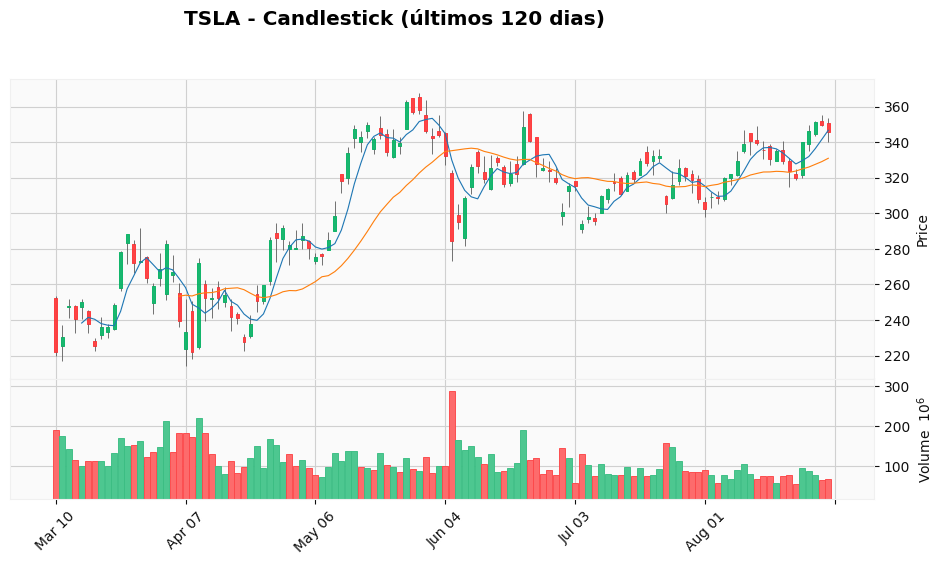

In [ ]:
# === Carregamento do dataset e visualização ===
PATH_CSV = '../Datasets/Tesla_stock_data.csv'
N_DAYS = 120  # parâmetro para o gráfico

# Ler CSV, ordenar e indexar por data
df = pd.read_csv(PATH_CSV, parse_dates=['Date']).sort_values('Date').set_index('Date')

# Forma do dataset
print(f'O Dataset tem {df.shape[0]} linhas, {df.shape[1]} colunas.\n')

# Verificação de NaNs e duplicados
print("Valores NaN (total):", df.isna().sum().sum(), '\n')
print("Linhas duplicadas (iguais):", df.duplicated().sum(), '\n')
print("Datas duplicadas no índice:", df.index.duplicated().sum(), '\n')

# Intervalo temporal
print("Período:", df.index.min().date(), "→", df.index.max().date(), "\n")

# Gráfico de velas (últimos N_DAYS) — OHLCV (Open, High, Low, Close, Volume)
ohlcv = df[['Open','High','Low','Close','Volume']].copy()
ohlcv_last = ohlcv.tail(N_DAYS)

mpf.plot(ohlcv_last,
         type='candle',
         mav=(5, 20),
         volume=True,
         title=f'TSLA - Candlestick (últimos {N_DAYS} dias)',
         style='yahoo',
         figsize=(12, 6),
         show_nontrading=False)


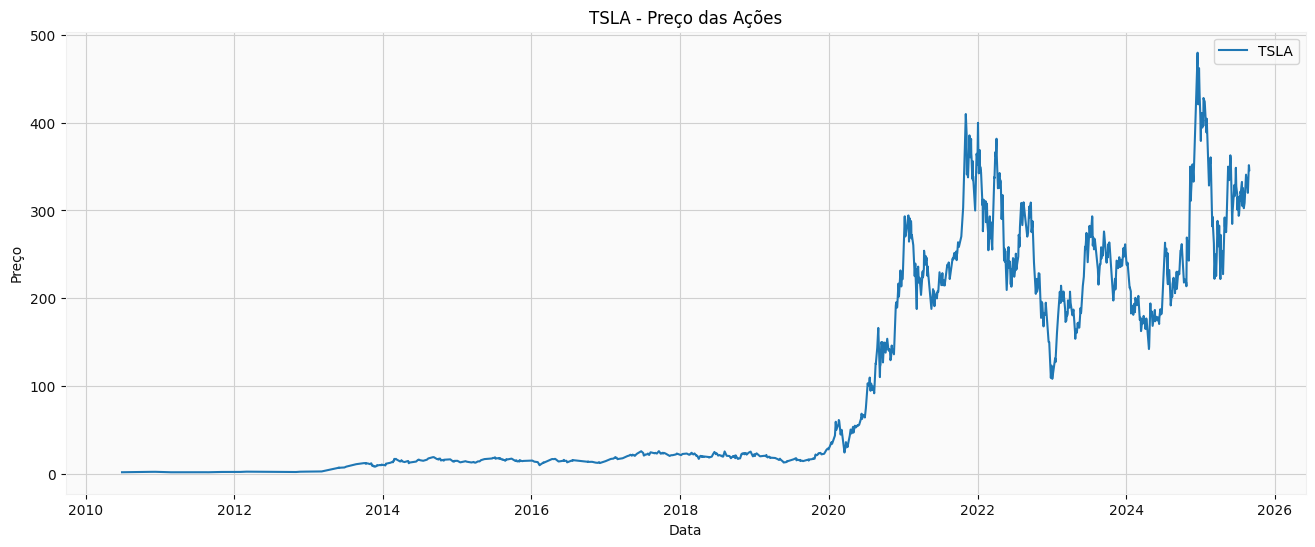

In [ ]:
# Passar coluna 'Close' para time series
ts_close = df['Close'].copy()

# Gráfico da time series
plt.figure(figsize=(16,6))
plt.plot(ts_close.index, ts_close, label="TSLA")
plt.title(f'TSLA - Preço das Ações')
plt.xlabel('Data')
plt.ylabel('Preço')
plt.legend()
plt.show()

In [ ]:
# === Features causais + split sklearn ===

# Features a criar
# Lags (t-1..t-10):
#       - Captam a memória curta/persistência típica dos preços (y_t ≈ y_{t-1}+ε_t)
#       e permitem que modelos aprendam relação de um dia para o outro.
# SMA5 e SMA20 (com shift(1)):
#       - Dão noção simples de tendência (≈ 1 semana e ≈ 1 mês) e suavizam ruído.
#       O `shift(1)` garante causalidade ("sem olhar para o futuro").
# Construção antes do split:
#       - Com `shift(1)`, evitamos **leakage** e mantemos continuidade nas janelas
#       (a SMA do início do teste usa apenas passado).


# Função para criar features na time serie
def make_features_close(ts_close: pd.Series, lags=10, sma_short=5, sma_long=20):
    """
    ts_close: pd.Series com índice temporal e o preço de fecho.
    Cria features causais:
      - lags: Close.shift(1..lags)
      - SMAs: médias móveis (sma_short, sma_long) com shift(1) para evitar leakage
    """
    fe = pd.DataFrame({'Close': ts_close}).copy()
    for l in range(1, lags + 1):
        fe[f'lag{l}'] = fe['Close'].shift(l)
    fe[f'sma_{sma_short}'] = fe['Close'].rolling(sma_short).mean().shift(1)
    fe[f'sma_{sma_long}']  = fe['Close'].rolling(sma_long).mean().shift(1)
    fe = fe.dropna()
    return fe

# Adicionar features
fe = make_features_close(ts_close)

# Separação das features do target (Close)
X = fe.drop(columns='Close')
y = fe['Close']

# Split temporal com sklearn (sem baralhar)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, shuffle=False)

print("Shapes → X_train:", X_train.shape, "| X_test:", X_test.shape)
print("Período treino →", X_train.index.min().date(), "→", X_train.index.max().date())
print("Período teste  →", X_test.index.min().date(),  "→", X_test.index.max().date(), "\n")


Shapes → X_train: (3036, 12) | X_test: (760, 12)
Período treino → 2010-07-28 → 2022-08-17
Período teste  → 2022-08-18 → 2025-08-28 



Baseline Naïve (persistência y_T): {'MAE': 79.38979353653757, 'RMSE': 90.86888855476828, 'R2': -0.7629556635544807} 



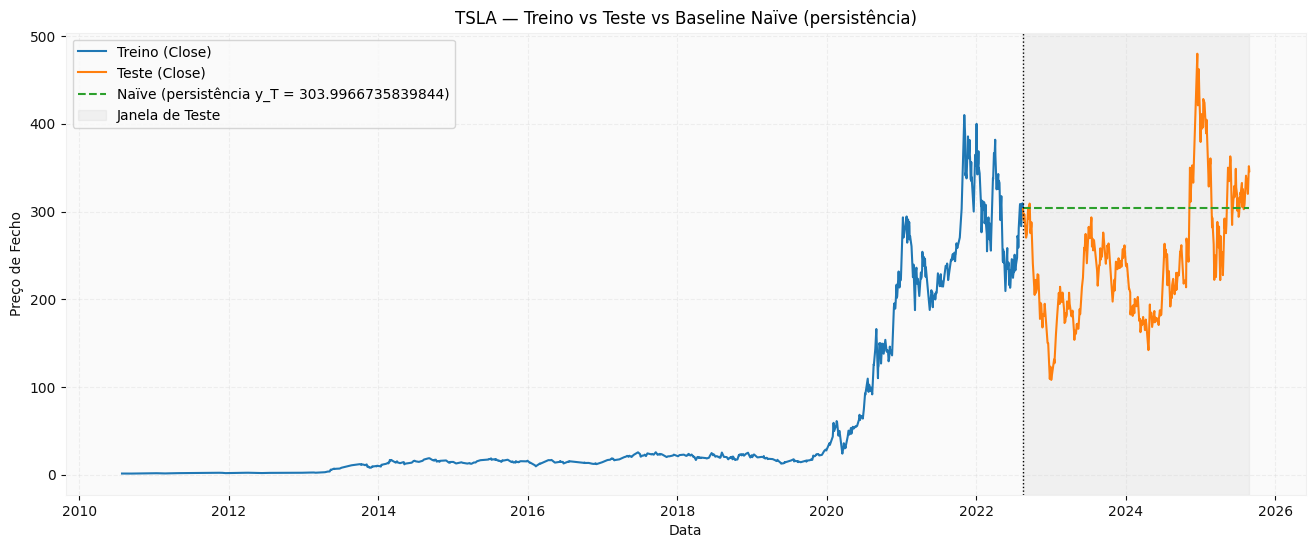

In [ ]:
# Modelo de referência
# Baseline Naïve (persistência estática): ŷ_{T+h|T} = y_T
# Onde y_T é o último valor observado no conjunto de treino.

# Dicionário para guardar resultados
results = {}

y_T = y_train.iloc[-1]                              # último Close do treino
y_pred_naive = pd.Series(y_T, index=y_test.index)   # linha horizontal no teste

results['Naive (persistência y_T)'] = metrics_dict(y_test, y_pred_naive)
print('Baseline Naïve (persistência y_T):', results['Naive (persistência y_T)'], '\n')

# Visualização Treino vs Teste vs Baseline Naïve
plt.figure(figsize=(16,6))

# Série real (treino e teste com cores distintas)
plt.plot(X_train.index, y_train.values, label='Treino (Close)', linewidth=1.5)
plt.plot(X_test.index,  y_test.values,  label='Teste (Close)',  linewidth=1.5)

# Baseline naïve (linha horizontal no período de teste)
plt.plot(y_pred_naive.index, y_pred_naive, '--', label=f'Naïve (persistência y_T = {y_T})')

# Marca e sombreado da janela de teste
plt.axvline(y_test.index.min(), color='k', linestyle=':', linewidth=1)
plt.axvspan(y_test.index.min(), y_test.index.max(), color='grey', alpha=0.08, label='Janela de Teste')

plt.title('TSLA — Treino vs Teste vs Baseline Naïve (persistência)')
plt.xlabel('Data')
plt.ylabel('Preço de Fecho')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()


Regressão Linear: {'MAE': 7.044514453245094, 'RMSE': 9.774003924328456, 'R2': 0.979603484660985} 



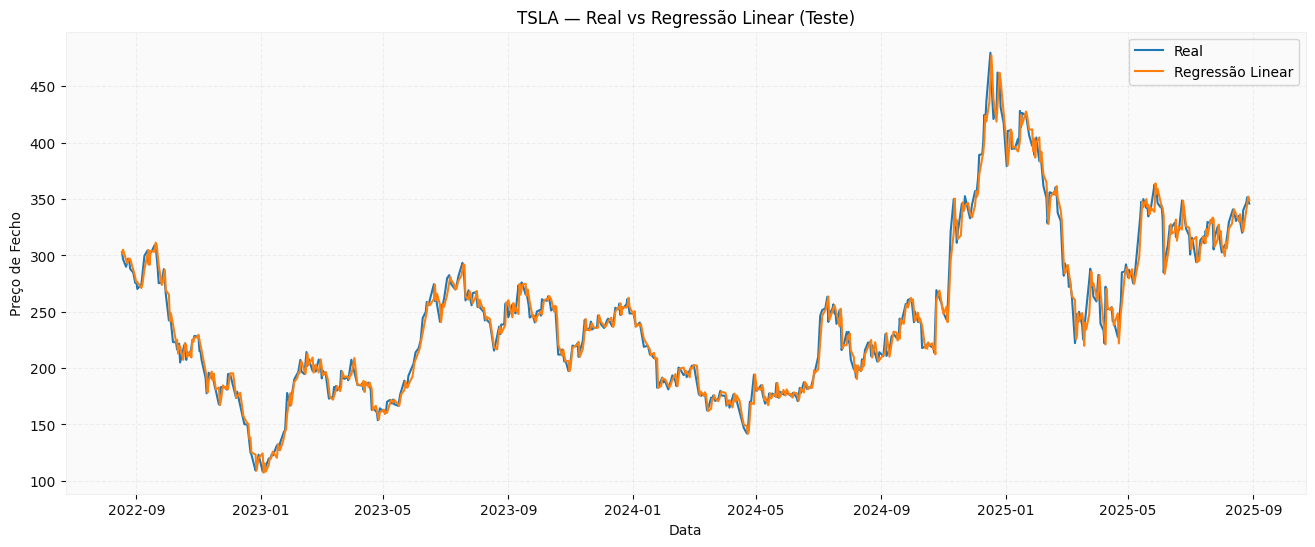

In [18]:
# === Regressão Linear ===

# Treino do modelo
lr = LinearRegression()
lr.fit(X_train, y_train)

# Previsões no teste
y_pred_lr = pd.Series(lr.predict(X_test), index=y_test.index)

# Métricas
results['Regressão Linear'] = metrics_dict(y_test, y_pred_lr)
print('Regressão Linear:', results['Regressão Linear'], '\n')

# Gráfico: Real vs Regressão Linear (teste)
plt.figure(figsize=(16,6))
plt.plot(y_test.index, y_test, label='Real')
plt.plot(y_pred_lr.index, y_pred_lr, label='Regressão Linear')
plt.title('TSLA — Real vs Regressão Linear (Teste)')
plt.xlabel('Data')
plt.ylabel('Preço de Fecho')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()


XGBoost: {'MAE': 12.085547055696185, 'RMSE': 18.217101355673066, 'R2': 0.9291451623132749} 



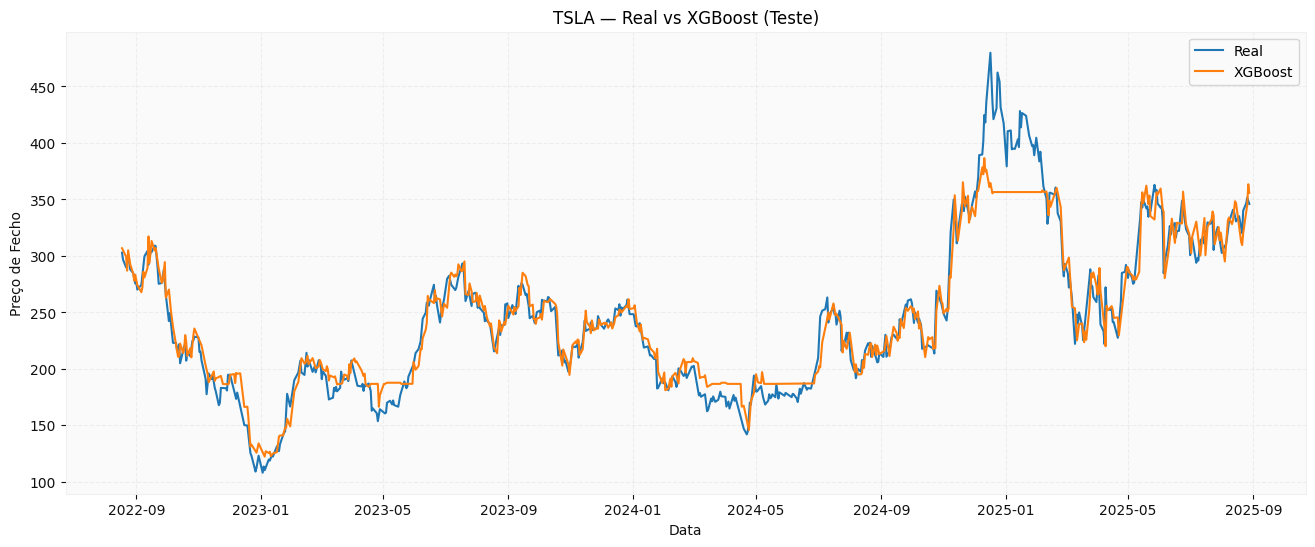

In [ ]:
# === XGBoost ===

# Treino do modelo
xgb = XGBRegressor(n_estimators=500,
                   learning_rate=0.05,
                   max_depth=6,
                   subsample=0.8,
                   colsample_bytree=0.8,
                   random_state=SEED,
                   objective='reg:squarederror',
                   n_jobs=-1)

xgb.fit(X_train, y_train)

# Previsões no teste
y_pred_xgb = pd.Series(xgb.predict(X_test), index=y_test.index)

# Métricas
results['XGBoost'] = metrics_dict(y_test, y_pred_xgb)
print('XGBoost:', results['XGBoost'], '\n')

# Gráfico: Real vs XGBoost (teste)
plt.figure(figsize=(16,6))
plt.plot(y_test.index, y_test.values, label='Real', linewidth=1.5)
plt.plot(y_pred_xgb.index, y_pred_xgb, label='XGBoost', linewidth=1.5)
plt.title('TSLA — Real vs XGBoost (Teste)')
plt.xlabel('Data'); plt.ylabel('Preço de Fecho')
plt.legend(); plt.grid(True, linestyle='--', alpha=0.3)
plt.show()


24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
LSTM: {'MAE': 9.072434796785053, 'RMSE': 12.194681716886866, 'R2': 0.9682494028658437} 



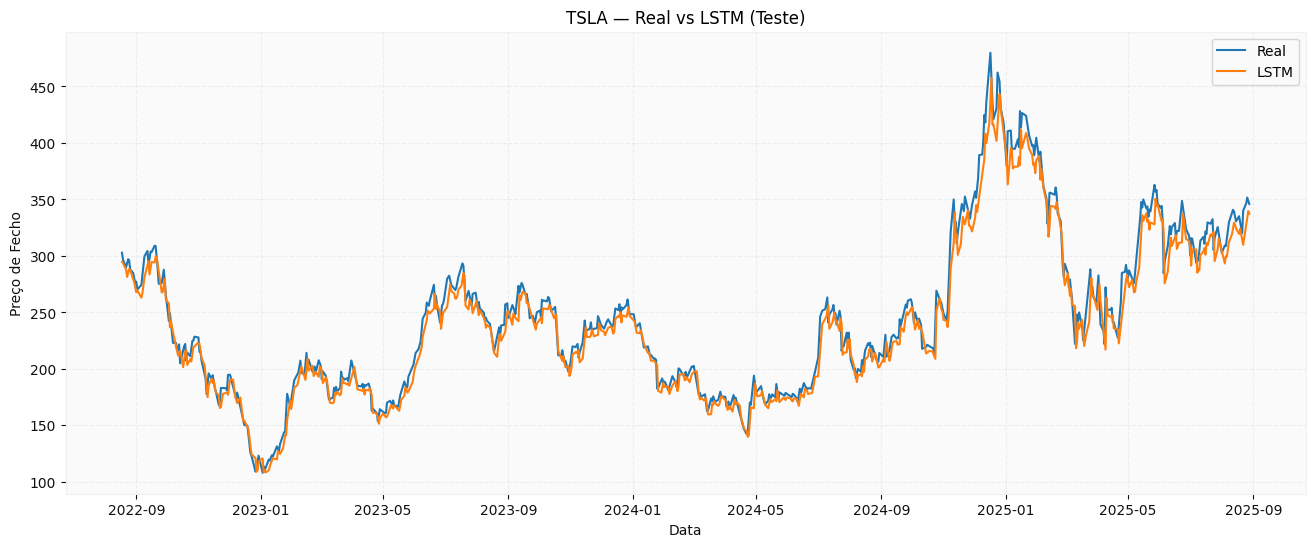

In [ ]:
# === LSTM ===

# 1) Split temporal sem baralhar)
ts_train, ts_test = train_test_split(ts_close, test_size=0.20, shuffle=False)

# 2) Normalização só com base no treino (evitar leakage)
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(ts_train.values.reshape(-1, 1))
test_scaled  = scaler.transform(ts_test.values.reshape(-1, 1))

# 3) Criar sequências (janelas) causais
window = 10
def make_sequences(arr, win):
    X, y = [], []
    for i in range(win, len(arr)):
        X.append(arr[i-win:i, 0])
        y.append(arr[i, 0])
    X = np.array(X); y = np.array(y)
    return X.reshape((X.shape[0], X.shape[1], 1)), y

X_lstm_train, y_lstm_train = make_sequences(train_scaled, window)

# Para o teste, usamos os dados da última janela do treino como ponto de partida para manter o contexto.
test_concat = np.vstack([train_scaled[-window:], test_scaled])

X_lstm_test, y_lstm_test  = make_sequences(test_concat, window)

# 4) Modelo LSTM simples
model = models.Sequential([layers.Input(shape=(window, 1)),
                           layers.LSTM(64),
                           layers.Dense(1)])

model.compile(optimizer='adam', loss='mse')

es = callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(X_lstm_train,
                    y_lstm_train,
                    validation_split=0.1,
                    epochs=100,
                    batch_size=32,
                    callbacks=[es],
                    verbose=0)

# 5) Previsões no teste (voltar à escala original)
y_pred_lstm_scaled = model.predict(X_lstm_test).reshape(-1, 1)
y_pred_lstm = scaler.inverse_transform(y_pred_lstm_scaled).ravel()

# Série prevista com o MESMO índice do ts_test (tamanhos coincidem)
y_pred_lstm_s = pd.Series(y_pred_lstm, index=ts_test.index, name='LSTM')

# 6) Avaliação alinhada ao y_test dos outros modelos (pode ser um pouco menor por causa dos lags/SMAs)
y_pred_lstm_aligned = y_pred_lstm_s.reindex(y_test.index).dropna()
y_true_aligned      = y_test.loc[y_pred_lstm_aligned.index]

results['LSTM'] = metrics_dict(y_true_aligned.values, y_pred_lstm_aligned.values)
print('LSTM:', results['LSTM'], '\n')

# 7) Gráfico: Real vs LSTM (teste)
plt.figure(figsize=(16,6))
plt.plot(y_true_aligned.index, y_true_aligned.values, label='Real', linewidth=1.5)
plt.plot(y_pred_lstm_aligned.index, y_pred_lstm_aligned, label='LSTM', linewidth=1.5)
plt.title('TSLA — Real vs LSTM (Teste)')
plt.xlabel('Data'); plt.ylabel('Preço de Fecho')
plt.legend(); plt.grid(True, linestyle='--', alpha=0.3)
plt.show()


Métricas (ordenadas por RMSE):
                               MAE     RMSE      R2
Regressão Linear           7.0445   9.7740  0.9796
LSTM                       9.0724  12.1947  0.9682
XGBoost                   12.0855  18.2171  0.9291
Naive (persistência y_T)  79.3898  90.8689 -0.7630 

Extras (MAPE %, Direção %):
                           MAPE (%)  Direção (%)
Modelo                                         
Regressão Linear              2.91        49.61
LSTM                          3.61        50.26
XGBoost                       4.93        45.26
Naïve (persistência y_T)     39.34         0.13 



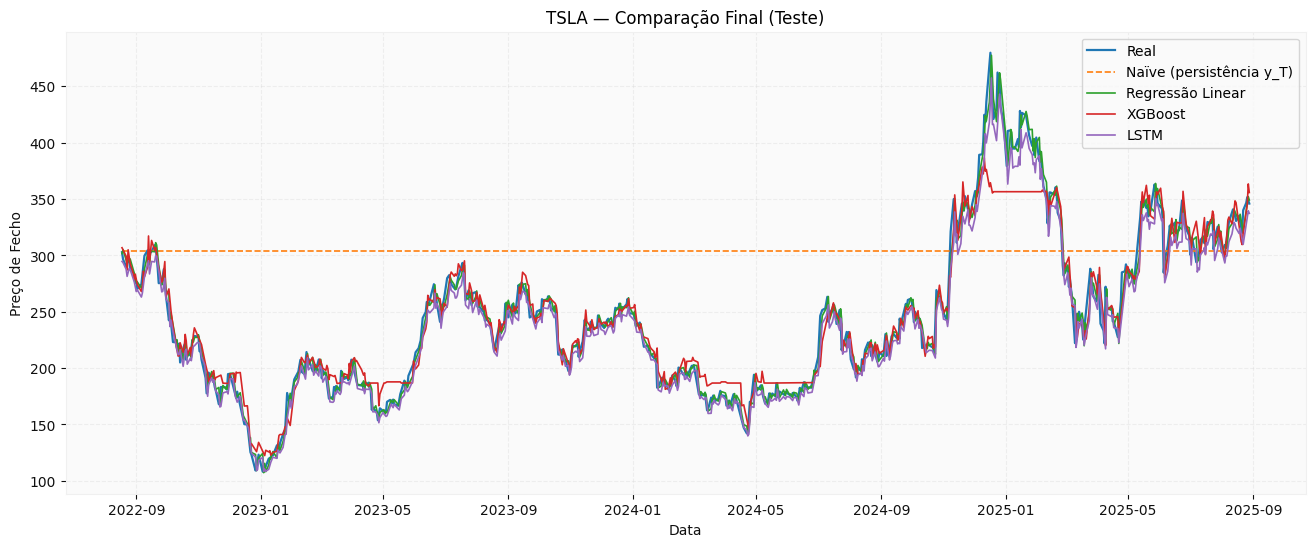

In [ ]:
# === Comparação Final (tabela + gráfico com todos os modelos) ===

# Tabela de métricas (já calculadas e guardadas em `results`)
metrics_df = pd.DataFrame(results).T[['MAE','RMSE','R2']].sort_values('RMSE')
print('Métricas (ordenadas por RMSE):\n', metrics_df.round(4), '\n')

# 2) Extras (opcional): MAPE e Acerto Direcional (subiu/desceu?)
def mape(y_true, y_pred):
    return (np.abs((y_true - y_pred) / y_true).mean() * 100)

extras_rows = []

# Naïve (persistência y_T)
if 'y_pred_naive' in locals():
    extras_rows.append(['Naïve (persistência y_T)',
                        mape(y_test, y_pred_naive),
                        (np.sign(y_test.diff()) == np.sign(y_pred_naive.diff())).mean() * 100])

# Regressão Linear
if 'y_pred_lr' in locals():
    extras_rows.append(['Regressão Linear',
                        mape(y_test, y_pred_lr),
                        (np.sign(y_test.diff()) == np.sign(y_pred_lr.diff())).mean() * 100])

# XGBoost
if 'y_pred_xgb' in locals():
    extras_rows.append(['XGBoost',
                        mape(y_test, y_pred_xgb),
                        (np.sign(y_test.diff()) == np.sign(y_pred_xgb.diff())).mean() * 100])

# LSTM (usar o alinhado ao y_test)
if 'y_pred_lstm_aligned' in locals():
    y_true_lstm = y_test.loc[y_pred_lstm_aligned.index]
    extras_rows.append(['LSTM',
                        mape(y_true_lstm, y_pred_lstm_aligned),
                        (np.sign(y_true_lstm.diff()) == np.sign(y_pred_lstm_aligned.diff())).mean() * 100])

if extras_rows:
    extras_df = pd.DataFrame(extras_rows, columns=['Modelo','MAPE (%)','Direção (%)']) \
                   .set_index('Modelo').sort_values('MAPE (%)')
    print('Extras (MAPE %, Direção %):\n', extras_df.round(2), '\n')

# 3) Gráfico conjunto (Real + todas as previsões disponíveis)
plt.figure(figsize=(16,6))
plt.plot(y_test.index, y_test.values, label='Real', linewidth=1.6)

if 'y_pred_naive' in locals():
    plt.plot(y_pred_naive.index, y_pred_naive, '--', label='Naïve (persistência y_T)', linewidth=1.2)
if 'y_pred_lr' in locals():
    plt.plot(y_pred_lr.index, y_pred_lr, label='Regressão Linear', linewidth=1.2)
if 'y_pred_xgb' in locals():
    plt.plot(y_pred_xgb.index, y_pred_xgb, label='XGBoost', linewidth=1.2)
if 'y_pred_lstm_aligned' in locals():
    plt.plot(y_pred_lstm_aligned.index, y_pred_lstm_aligned, label='LSTM', linewidth=1.2)

plt.title('TSLA — Comparação Final (Teste)')
plt.xlabel('Data'); plt.ylabel('Preço de Fecho')
plt.legend(); plt.grid(True, linestyle='--', alpha=0.3)
plt.show()


## Resultados — Comparação de Modelos

**Principais conclusões**
- **Regressão Linear** aproxima a identidade (peso alto em `lag1`) e **supera os modelos não lineares** (XGBoost e LSTM) neste setup.
- **XGBoost** produz traçados em **degraus** (piecewise constant) e, sem validação temporal/early stopping, **degrada o RMSE**.
- **LSTM** não supera a baseline forte neste horizonte e sem variáveis exógenas.

**Notas**
- A baseline **naïve persistente** $\hat y_{T+h|T}=y_T$ é **apenas pedagógica** e tem desempenho fraco neste contexto.

**XGBoost**
- Apesar de ter sido o **pior modelo na configuração base**, vamos **adotá-lo como modelo-alvo para a fase de afinação**, explorando tuning de hiperparâmetros e validação temporal. O objetivo é mostrar o processo típico de otimização em ML e avaliar se, com ajustes, o XGBoost se consegue aproximar ou superar as linhas de base.


Melhores parâmetros (CV temporal):
{'subsample': 1.0, 'reg_lambda': 10.0, 'reg_alpha': 1.0, 'n_estimators': 1400, 'min_child_weight': 7, 'max_depth': 6, 'learning_rate': 0.1, 'gamma': 1.0, 'colsample_bytree': 0.9}
RMSE médio (CV): 39.3673

XGBoost (tuned+ES): {'MAE': 21.249489814356753, 'RMSE': 38.45538230305169, 'R2': 0.6842631842883826}
Best iteration: 150


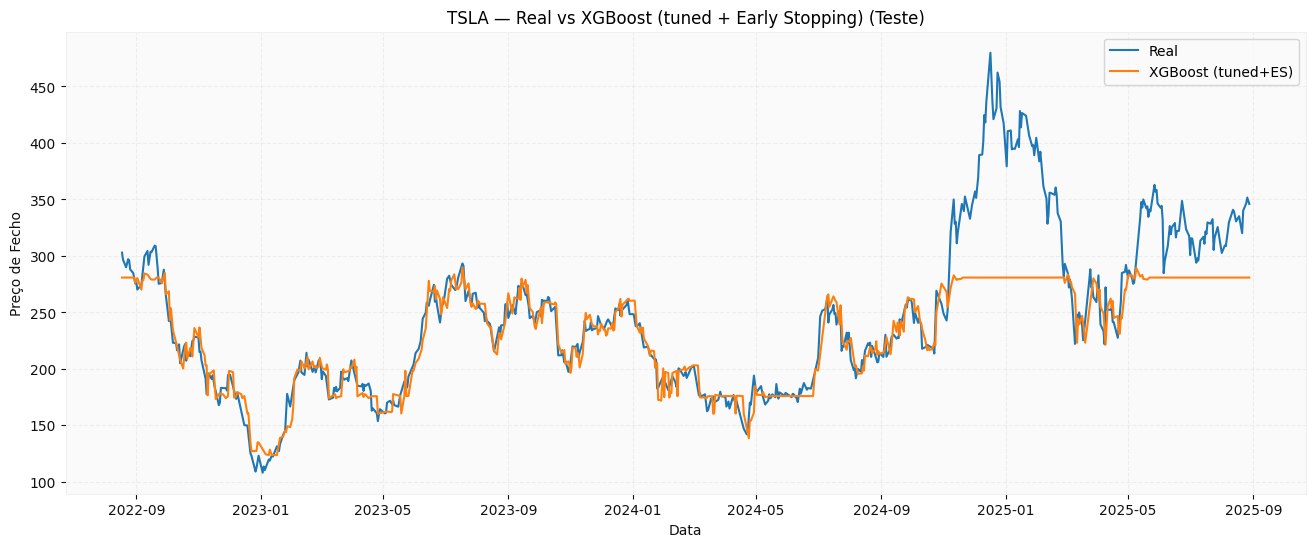

In [ ]:
# === XGBoost — Tuning com TimeSeriesSplit + RandomizedSearch (com Early Stopping) ===

# Dic de parametros e RandomizedSearchCV com TimeSeriesSplit
param_dist = {
    "n_estimators":     [200, 400, 600, 800, 1000, 1400, 1800, 2200],
    "learning_rate":    [0.01, 0.02, 0.03, 0.05, 0.07, 0.1, 0.15, 0.2],
    "max_depth":        [3, 4, 5, 6, 7, 8],
    "min_child_weight": [1, 2, 3, 5, 7],
    "subsample":        [0.6, 0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0],
    "reg_lambda":       [0.0, 0.1, 1.0, 3.0, 5.0, 10.0],
    "reg_alpha":        [0.0, 0.1, 0.5, 1.0, 2.0],
    "gamma":            [0.0, 0.1, 0.5, 1.0]
}

xgb_base = XGBRegressor(
    objective="reg:squarederror",
    random_state=SEED,
    n_jobs=-1
)

tscv = TimeSeriesSplit(n_splits=5)

rsearch = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=40,
    scoring="neg_root_mean_squared_error",
    cv=tscv,
    n_jobs=-1,
    random_state=SEED,
    verbose=0
)

# 2) Tuning no treino (CV temporal)
rsearch.fit(X_train, y_train)

best_params = rsearch.best_params_
best_cv_rmse = -rsearch.best_score_

print("Melhores parâmetros (CV temporal):")
print(best_params)
print(f"RMSE médio (CV): {best_cv_rmse:.4f}\n")

# 3) Validação temporal simples (últimos 10% do treino) + Early Stopping (no construtor)
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.10, shuffle=False)

# Dar "folga" ao ES: aumentar n_estimators mantendo o resto dos best_params
best_params_es = best_params.copy()
best_params_es["n_estimators"] = max(2000, best_params.get("n_estimators", 1000))

xgb_tuned_es = XGBRegressor(
    **best_params_es,
    objective="reg:squarederror",
    random_state=SEED,
    n_jobs=-1,
    eval_metric="rmse",          
    early_stopping_rounds=200    
)

xgb_tuned_es.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    verbose=False
)

# 4) Previsões no teste + métricas
y_pred_xgb_tuned = pd.Series(xgb_tuned_es.predict(X_test), index=y_test.index)

results['XGBoost (tuned+ES)'] = metrics_dict(y_test, y_pred_xgb_tuned)
print('XGBoost (tuned+ES):', results['XGBoost (tuned+ES)'])

if hasattr(xgb_tuned_es, "best_iteration"):
    print("Best iteration:", xgb_tuned_es.best_iteration)

# 5) Gráfico
plt.figure(figsize=(16,6))
plt.plot(y_test.index, y_test, label='Real', linewidth=1.5)
plt.plot(y_pred_xgb_tuned.index, y_pred_xgb_tuned, label='XGBoost (tuned+ES)', linewidth=1.5)
plt.title('TSLA — Real vs XGBoost (tuned + Early Stopping) (Teste)')
plt.xlabel('Data'); plt.ylabel('Preço de Fecho')
plt.legend(); plt.grid(True, linestyle='--', alpha=0.3)
plt.show()


## Melhorar o modelo — foco em *features*

**O que aconteceu**
- Com `lag1..lag10`, `sma_5`, `sma_20`, a **Regressão Linear** foi a melhor; o **XGBoost** ficou abaixo.
- O *tuning* com CV temporal empurrou o XGBoost para combinações que **subajustam** em **níveis de preço** (erro médio em CV alto e pouco transferível para o teste).
- *Early stopping* não trouxe ganhos práticos neste setup de 1 passo à frente.

**Diagnóstico**
- Em preços diários, a dinâmica é dominada por **persistência** (valor de ontem).  
- Com *features* só de nível (lags/SMAs), o XGBoost tem pouco sinal não linear para explorar — tende a aproximar o `lag1`.

**Próximos passos**
1. **Enriquecer *features* de forma causal** (sempre com `shift(1)`):
   - **Momentum**: `ret1` (retorno log do dia anterior) e `ret5` (5 dias).
   - **Tendência**: `dist_sma20` (distância relativa ao SMA20).
   - **Volatilidade**: `vol10` (desvio padrão de retornos em 10 dias).
   > Mantemos também `lag1..lag10`, `sma_5`, `sma_20`.
2. **Re-treinar** XGBoost com estas *features+* no **mesmo split temporal**, e comparar com as linhas de base.
3. **Decidir**: se o XGBoost ganhar (mesmo que pouco) em RMSE/MAPE, fica como modelo final de ML; se não, documentamos que **neste horizonte e alvo em nível**, a Linear permanece mais adequada.

**Critério de sucesso**
- Melhoria de **RMSE** (principal) e **MAPE** no período de **teste** face ao XGBoost base e à Linear.  
- Sem *leakage*: todas as transformações conhecidas a \(t-1\).

**Notas de implementação**
- Construir *features* **antes** do split é seguro aqui porque aplicamos `shift(1)` (causalidade).  
- Árvores **não precisam de *scaling***; a Linear pode beneficiar marginalmente mas não é obrigatório.  
- Mantemos o pipeline e métricas exatamente como até agora — só acrescentamos colunas.


Shapes → X_train: (3036, 16) | X_test: (760, 16)
Período treino → 2010-07-28 → 2022-08-17
Período teste  → 2022-08-18 → 2025-08-28 

XGBoost (feat+): {'MAE': 10.918119962591874, 'RMSE': 17.115189342449735, 'R2': 0.9374576242757842} 

Comparação XGBoost base vs feat+:
                        MAE       RMSE        R2
XGBoost (base)   12.085547  18.217101  0.929145
XGBoost (feat+)  10.918120  17.115189  0.937458 



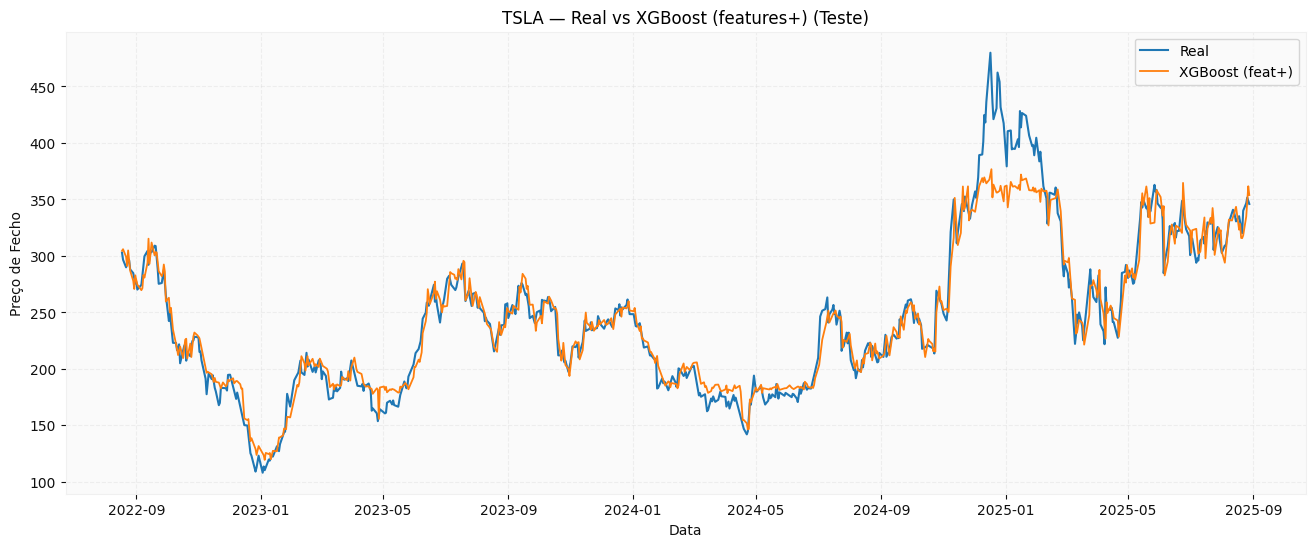

Top-12 importâncias (XGB feat+):
 lag1      0.384436
lag6      0.288823
lag2      0.132959
lag9      0.076537
sma_5     0.039541
lag5      0.024502
sma_20    0.021071
lag10     0.016759
lag8      0.006944
lag7      0.004642
lag3      0.002614
lag4      0.000304
dtype: float32


In [ ]:
# === Features + (causais) + XGBoost ===

def make_features_close_plus(ts_close: pd.Series, lags=10):
    """
    Features causais para prever Close_t (1 passo):
      - lags de nível: lag1..lag{lags}
      - SMAs: sma_5, sma_20  (com shift(1))
      - Momentum (retornos log): ret1, ret5   (com shift(1))
      - Tendência: dist_sma20  (Close vs SMA20, com shift(1))
      - Volatilidade: vol10 (std de retornos log 10d, com shift(1))
    """
    fe = pd.DataFrame({'Close': ts_close.astype('float64')}).copy()

    # Lags de nível
    for l in range(1, lags + 1):
        fe[f'lag{l}'] = fe['Close'].shift(l)

    # SMAs (causais)
    fe['sma_5']  = fe['Close'].rolling(5).mean().shift(1)
    sma20        = fe['Close'].rolling(20).mean()
    fe['sma_20'] = sma20.shift(1)

    # Log-preço e retornos (momentum)
    logp = np.log(fe['Close'])
    fe['ret1'] = logp.diff().shift(1)          # type: ignore # retorno de 1 dia (t-1)
    fe['ret5'] = logp.diff(5).shift(1)         # type: ignore # retorno de 5 dias (t-1)

    # Tendência: distância relativa à SMA20 (causal)
    fe['dist_sma20'] = (fe['Close'] / sma20 - 1).shift(1)

    # Volatilidade: std de retornos log em 10 dias (causal)
    vol10 = logp.diff().rolling(10).std() # type: ignore
    fe['vol10'] = vol10.shift(1)

    return fe.dropna()

# 1) Construção das features+
fe_plus = make_features_close_plus(ts_close, lags=10)

X_plus = fe_plus.drop(columns='Close')
y_plus = fe_plus['Close']

# 2) Split temporal (sem baralhar)
Xp_train, Xp_test, yp_train, yp_test = train_test_split(X_plus, y_plus, test_size=0.20, shuffle=False)

print("Shapes → X_train:", Xp_train.shape, "| X_test:", Xp_test.shape)
print("Período treino →", Xp_train.index.min().date(), "→", Xp_train.index.max().date())
print("Período teste  →", Xp_test.index.min().date(),  "→", Xp_test.index.max().date(), "\n")

# 3) XGBoost 
xgb_plus = XGBRegressor(
    n_estimators=800,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=1,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    reg_alpha=0.0,
    gamma=0.0,
    objective='reg:squarederror',
    random_state=SEED,
    n_jobs=-1
)
xgb_plus.fit(Xp_train, yp_train)

# 4) Previsões + métricas
y_pred_xgb_plus = pd.Series(xgb_plus.predict(Xp_test), index=yp_test.index, name='XGB_feat+')

results['XGBoost (feat+)'] = metrics_dict(yp_test, y_pred_xgb_plus)
print('XGBoost (feat+):', results['XGBoost (feat+)'], '\n')

# Comparar rapidamente com o XGB base se existir
if 'XGBoost' in results:
    comp = pd.DataFrame({
        'XGBoost (base)': results['XGBoost'],
        'XGBoost (feat+)': results['XGBoost (feat+)']
    }).T[['MAE','RMSE','R2']]
    print('Comparação XGBoost base vs feat+:\n', comp, '\n')

# 5) Gráfico
plt.figure(figsize=(16,6))
plt.plot(yp_test.index, yp_test, label='Real', linewidth=1.5)
plt.plot(y_pred_xgb_plus.index, y_pred_xgb_plus, label='XGBoost (feat+)', linewidth=1.3)
plt.title('TSLA — Real vs XGBoost (features+) (Teste)')
plt.xlabel('Data'); plt.ylabel('Preço de Fecho')
plt.legend(); plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

# 6) Importâncias das features
imp = pd.Series(xgb_plus.feature_importances_, index=Xp_train.columns).sort_values(ascending=False)
print("Top-12 importâncias (XGB feat+):\n", imp.head(12))



### Ajuste de *features* — síntese e próximo passo

- Ao adicionar *features causais* (momentum, tendência e volatilidade) ao conjunto base (`lag1..lag10`, `sma_5`, `sma_20`), o **XGBoost melhorou** de **RMSE ≈ 18.22** para **≈ 17.12** (↓ ~6%) e **MAE** também desceu (~9.7%).
- As **importâncias** continuam dominadas por `lag1` (e outros lags), com contribuições menores de SMAs; mesmo assim, as *features+* ajudaram a modelo a particionar melhor o espaço.
- **Próximo passo**: **aparar as features** com importância muito baixa (threshold simples, e.g. > 0.01), re-treinar o XGBoost com o conjunto reduzido (“slim”) e **comparar**.  
  Objetivo: reduzir ruído/complexidade e tentar **espremer mais um pouco o RMSE** mantendo o modelo mais simples e robusto.


Importâncias (todas):
 lag1          0.384436
lag6          0.288823
lag2          0.132959
lag9          0.076537
sma_5         0.039541
lag5          0.024502
sma_20        0.021071
lag10         0.016759
lag8          0.006944
lag7          0.004642
lag3          0.002614
lag4          0.000304
dist_sma20    0.000276
ret5          0.000265
vol10         0.000183
ret1          0.000145
dtype: float32 

Features mantidas (8): ['lag1', 'lag6', 'lag2', 'lag9', 'sma_5', 'lag5', 'sma_20', 'lag10'] 

Comparação XGBoost:
                        MAE       RMSE        R2
XGBoost (base)   12.085547  18.217101  0.929145
XGBoost (feat+)  10.918120  17.115189  0.937458
XGBoost (slim)   11.889675  17.121412  0.937412 



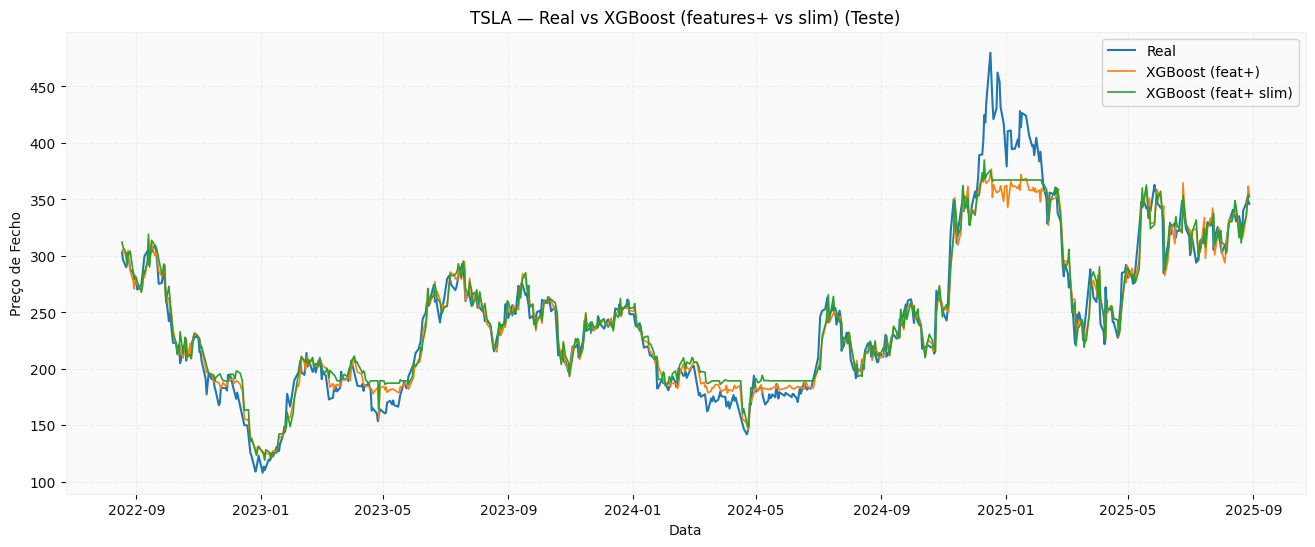

In [ ]:
# === Aparar features por importância e re-treinar XGBoost ===

# 1) Importâncias completas (ordenadas)
imp_full = pd.Series(xgb_plus.feature_importances_, index=Xp_train.columns).sort_values(ascending=False)
print("Importâncias (todas):\n", imp_full, "\n")

# 2) Seleção simples: manter só features com importância > 0.01
keep_feats = imp_full[imp_full > 0.01].index.tolist()
print(f"Features mantidas ({len(keep_feats)}):", keep_feats, "\n")

Xp_train_sel = Xp_train[keep_feats]
Xp_test_sel  = Xp_test[keep_feats]

# 3) XGBoost "slim" (mesmo setup base)
xgb_slim = XGBRegressor(
    n_estimators=800,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=1,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    reg_alpha=0.0,
    gamma=0.0,
    objective='reg:squarederror',
    random_state=SEED,
    n_jobs=-1
)
xgb_slim.fit(Xp_train_sel, yp_train)

y_pred_xgb_slim = pd.Series(xgb_slim.predict(Xp_test_sel), index=yp_test.index, name='XGB_feat_slim')

# 4) Métricas e comparação
res_slim = metrics_dict(yp_test, y_pred_xgb_slim)
results['XGBoost (feat+ slim)'] = res_slim

comp = pd.DataFrame({
    'XGBoost (base)':   results.get('XGBoost', {}),
    'XGBoost (feat+)':  results.get('XGBoost (feat+)', {}),
    'XGBoost (slim)':   results.get('XGBoost (feat+ slim)', {})
}).T[['MAE','RMSE','R2']]
print('Comparação XGBoost:\n', comp, '\n')

# 5) Gráfico
plt.figure(figsize=(16,6))
plt.plot(yp_test.index, yp_test, label='Real', linewidth=1.5)
plt.plot(y_pred_xgb_plus.index, y_pred_xgb_plus, label='XGBoost (feat+)', linewidth=1.2)
plt.plot(y_pred_xgb_slim.index, y_pred_xgb_slim, label='XGBoost (feat+ slim)', linewidth=1.2)
plt.title('TSLA — Real vs XGBoost (features+ vs slim) (Teste)')
plt.xlabel('Data'); plt.ylabel('Preço de Fecho')
plt.legend(); plt.grid(True, linestyle='--', alpha=0.3)
plt.show()


### Seleção de *features*
A **filtragem por importância** (> 0,01) não trouxe ganhos: o RMSE manteve-se praticamente igual e o MAE piorou ligeiramente.  
Mantemos, por isso, o conjunto **features+** completo, que apresentou a melhor performance no teste (RMSE ≈ 17,12).



Métricas finais — XGBoost (features+): {'MAE': 10.918119962591874, 'RMSE': 17.115189342449735, 'R2': 0.9374576242757842} 

Resumo de métricas (teste):
                                 MAE       RMSE        R2
Regressão Linear           7.044514   9.774004  0.979603
LSTM                       9.072435  12.194682  0.968249
XGBoost (feat+)           10.918120  17.115189  0.937458
XGBoost (final)           10.918120  17.115189  0.937458
XGBoost (feat+ slim)      11.889675  17.121412  0.937412
XGBoost                   12.085547  18.217101  0.929145
XGBoost (tuned+ES)        21.249490  38.455382  0.684263
Naive (persistência y_T)  79.389794  90.868889 -0.762956 



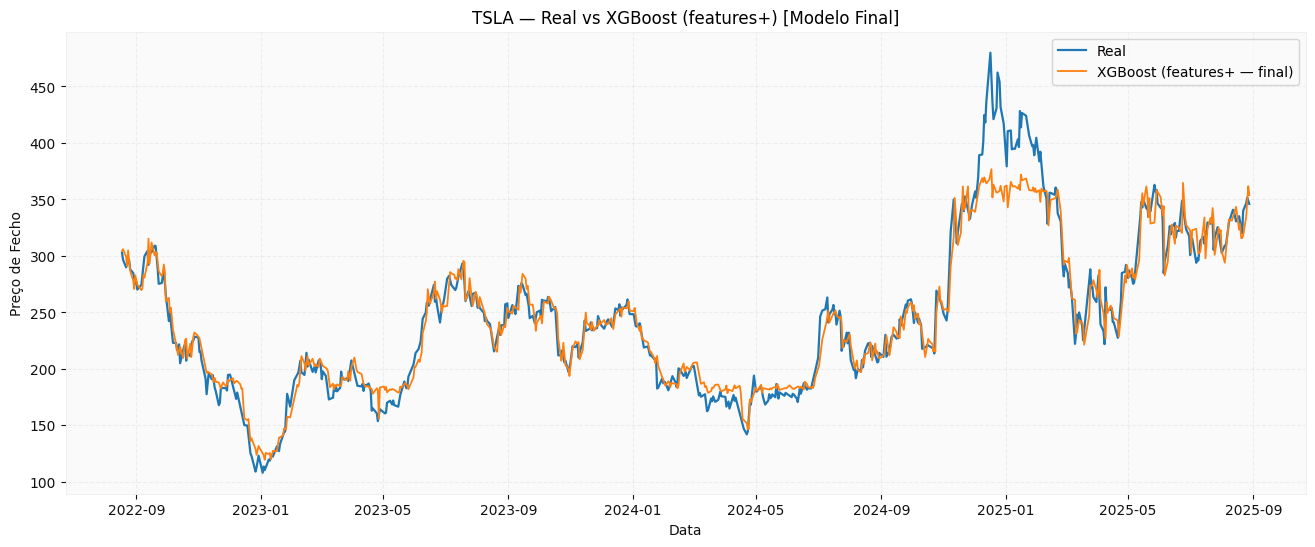

Predições guardadas em: ../Outputs\tsla_preds_xgb_features_plus.csv
Métricas guardadas em: ../Outputs\tsla_metrics_xgb_features_plus.csv
Modelo XGBoost guardado em: ../Outputs\xgb_features_plus_model.json
Importâncias guardadas em: ../Outputs\xgb_features_plus_importances.csv


In [ ]:
# === Modelo final (XGBoost features+) — fixar, avaliar, exportar ===

# 1) Fixar "modelo final" com o melhor setup
model_final = xgb_plus                 # XGBoost (features+) já treinado
y_pred_final = y_pred_xgb_plus.copy()  # previsões no teste (Series indexada)

# 2) Métricas finais (teste)
final_metrics = metrics_dict(yp_test, y_pred_final)
print("Métricas finais — XGBoost (features+):", final_metrics, "\n")

# 3) Tabela de comparação (se tiveres outras no 'results', mantém; caso contrário, só o final)
results['XGBoost (final)'] = final_metrics
metrics_df = pd.DataFrame(results).T[['MAE','RMSE','R2']].sort_values('RMSE')
print("Resumo de métricas (teste):\n", metrics_df, "\n")

# 4) Gráfico final
plt.figure(figsize=(16,6))
plt.plot(yp_test.index, yp_test, label='Real', linewidth=1.6)
plt.plot(y_pred_final.index, y_pred_final, label='XGBoost (features+ — final)', linewidth=1.3)
plt.title('TSLA — Real vs XGBoost (features+) [Modelo Final]')
plt.xlabel('Data'); plt.ylabel('Preço de Fecho')
plt.legend(); plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

# 5) Export: previsões, métricas e modelo
OUTPUT_DIR = '../Outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# 5.1 Previsões (CSV)
preds_df = pd.DataFrame({
    'Real': yp_test,
    'XGB_features_plus': y_pred_final
})
preds_path = os.path.join(OUTPUT_DIR, 'tsla_preds_xgb_features_plus.csv')
preds_df.to_csv(preds_path, index_label='Date')
print(f"Predições guardadas em: {preds_path}")

# 5.2 Métricas (CSV)
metrics_out = pd.DataFrame([final_metrics], index=['XGBoost_features_plus'])
metrics_path = os.path.join(OUTPUT_DIR, 'tsla_metrics_xgb_features_plus.csv')
metrics_out.to_csv(metrics_path)
print(f"Métricas guardadas em: {metrics_path}")

# 5.3 Modelo (ficheiro JSON ou pickle)
model_json_path = os.path.join(OUTPUT_DIR, 'xgb_features_plus_model.json')
model_final.get_booster().save_model(model_json_path)
print(f"Modelo XGBoost guardado em: {model_json_path}")

# (Opcional) Importâncias (CSV) — úteis para o relatório
imp = pd.Series(model_final.feature_importances_, index=Xp_train.columns).sort_values(ascending=False)
imp_path = os.path.join(OUTPUT_DIR, 'xgb_features_plus_importances.csv')
imp.to_csv(imp_path, header=['importance'])
print(f"Importâncias guardadas em: {imp_path}")


## Conclusões do Caso Prático (ML)

**Pipeline resumido.**  
1) Limpeza e ordenação temporal.  
2) Variáveis causais (*features*) sem *leakage*: `lag1..lag10`, `sma_5`, `sma_20` (tudo com `shift(1)`).  
3) Separação temporal (sem *shuffle*) e baselines.  
4) Modelos: **Regressão Linear** (referência) e **XGBoost** (modelo de ML alvo).  
5) Avaliação por **RMSE**, **MAE**, **R²** e comparação gráfica.

**O que observámos.**  
- Em 1 passo à frente de **níveis de preço**, a **persistência** domina; a baseline **Naive (lag1)** é muito forte e a **Regressão Linear** aproxima a identidade.  
- O **XGBoost (base)** ficou abaixo da Linear, mas com *feature engineering* causal adicional (**features+**: momentum, tendência e volatilidade) **melhorou de RMSE ≈ 18,22 para ≈ 17,12** (↓ ~6%) e o **MAE** também desceu (~9,7%).  
- As **importâncias** do XGBoost concentram-se em `lag1` e noutros lags; as novas variáveis contribuíram indiretamente, permitindo partições mais eficazes.  
- A **filtragem por importância** (> 0,01) **não** trouxe ganhos; mantivemos o conjunto **features+** completo.

**Modelo final.**  
Adotámos o **XGBoost com features+** como **modelo final de ML**, por:
- ser o foco do projeto (ML, não DL),
- apresentar **melhoria consistente** face ao XGBoost base,
- permitir **interpretação** via importâncias das variáveis.

**Limitações e nota prática.**  
- Em horizonte de 1 dia e alvo em **níveis**, não é expectável ultrapassar claramente a Naive/Linear — o ruído e mudanças de regime limitam o sinal.  
- Priorizou-se **simplicidade**, **causalidade** e uma **avaliação temporal honesta** (sem *leakage*).

**Entrega.**  
- Previsões, métricas e o modelo XGBoost (features+) foram guardados em `../Outputs/` (CSV/JSON).

> **Resumo:** Com foco em ML, a estratégia vencedora foi **reforçar o sinal** através de *feature engineering* causal. O **XGBoost (features+)** é o modelo final selecionado, com ganhos claros face ao XGBoost base e avaliação temporal consistente.
